# Data Loading and Initial Exploration
Objective

Understand the dataset structure, size, data types, and overall quality.

Findings
- Dataset contains retail sales transaction records.
- Includes customer, product, region, and sales information.
- Initial inspection helps identify missing values and data types.

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [182]:
data = pd.read_csv('train.csv')
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [183]:
data.shape

(9800, 18)

In [184]:
data.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [379]:
data.describe()

,row_id,order_date,ship_date,sales,delivery_days,year,quarter
count,9800.000000,9800,9800,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,230.769059,3.961122,2016.724184,2.885816
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,0.444000,0.000000,2015.000000,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,17.248000,3.000000,2016.000000,2.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,54.490000,4.000000,2017.000000,3.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,210.605000,5.000000,2018.000000,4.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,22638.480000,7.000000,2018.000000,4.000000
std,2829.160653,NaN,NaN,626.651875,1.749614,1.123984,1.057449


# Data Cleaning and Preprocessing

Steps Performed
Standardized column names.
Converted order_date and ship_date to datetime format.
Handled missing values in postal_code.

Created new features:
- delivery_days
- year
- month
- quarter

# Findings
- Data was successfully transformed into an analysis-ready format.
- New features enable time-based and logistics analysis.

In [186]:
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [187]:
data.duplicated().sum()

np.int64(0)

In [188]:
data.columns = data.columns.str.strip().str.lower().str.replace(" " , "_")
data.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [189]:
data['order_date'] = pd.to_datetime(data['order_date'] ,format = ('%d/%m/%Y') ,  errors = 'coerce')
data['ship_date'] = pd.to_datetime(data['ship_date']  , format = ('%d/%m/%Y'), errors = 'coerce')

In [190]:
data['postal_code'] = data['postal_code'].fillna("Unknown")

In [270]:
data['delivery_days'] = (data['ship_date'] - data['order_date']).dt.days
data.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,delivery_days,year,month,quarter
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3,2017,November,4
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,2017,November,4
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4,2017,June,2
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7,2016,October,4
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7,2016,October,4


In [271]:
data['year'] = data['order_date'].dt.year
data['month'] = data['order_date'].dt.month_name()
data['quarter'] = data['order_date'].dt.quarter

# **EDA**

# Sales Performance by Category
**Objective**

Identify which product categories generate the most revenue.

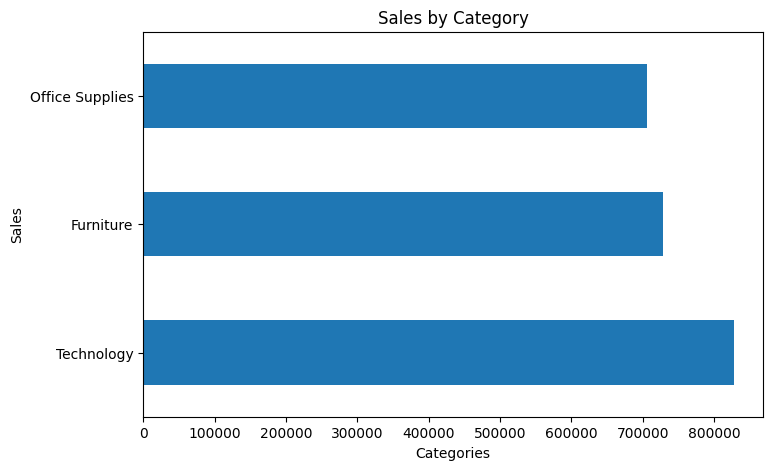

In [342]:
category_sales = (data.groupby('category')['sales'].sum().sort_values(ascending=False))

plt.figure(figsize=(8, 5))
category_sales.plot(kind='barh')
plt.title('Sales by Category')
plt.xlabel('Categories')
plt.ylabel('Sales')
plt.show()

# Insight
- Technology generated the highest sales.
- Furniture and Office Supplies followed behind.
- Technology products contribute significantly to overall revenue.

# Regional Sales Analysis
**Objective**

Compare sales performance across regions.

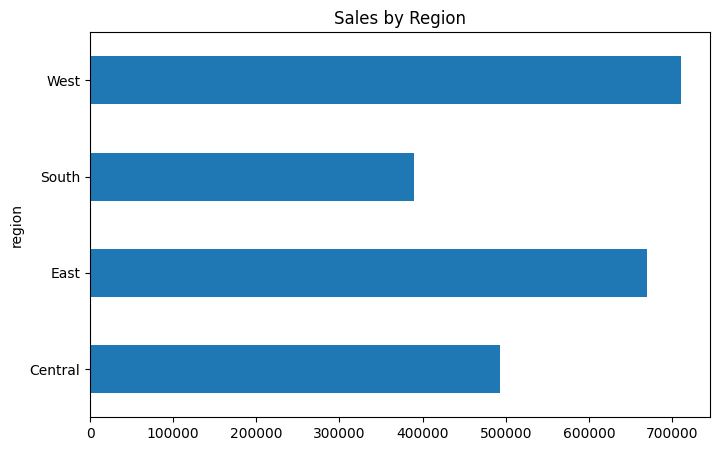

In [273]:
regional_sales = (data.groupby('region')['sales'].sum())

plt.figure(figsize=(8, 5))
regional_sales.plot(kind = 'barh')
plt.title('Sales by Region')
plt.show()

# Insight
- West region generated the highest sales.
- East region closely followed.
- South region recorded the lowest sales performance.

# Monthly Sales Trend Analysis
**Objective**

Analyze sales patterns over time.

In [351]:
data['ymonth'] = data['order_date'].dt.strftime('%Y-%m')

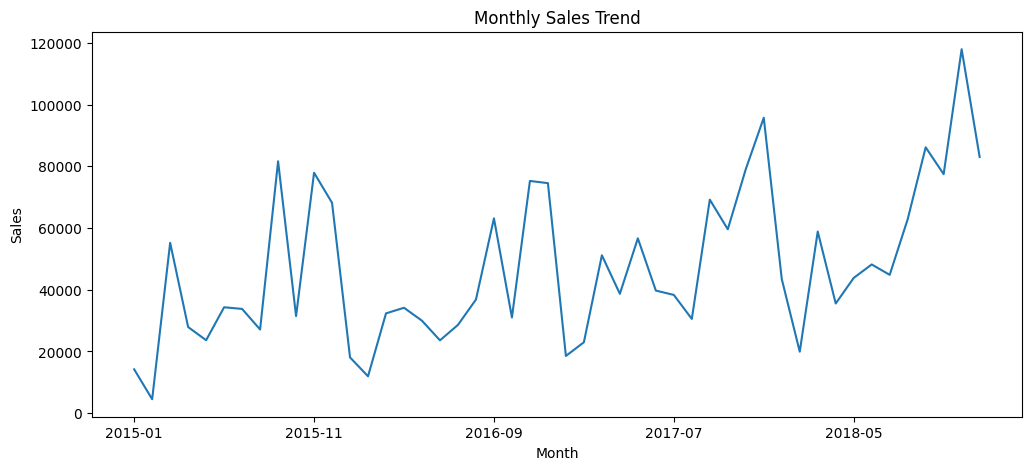

In [352]:
monthly_sales = (data.groupby('ymonth')['sales'].sum())

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

# Insight
- Sales generally show an upward trend over the years.
- Several seasonal peaks are visible.
- Business growth is evident through increasing monthly revenue.

# Top 10 Customers Analysis
**Objective**

Identify the most valuable customers.

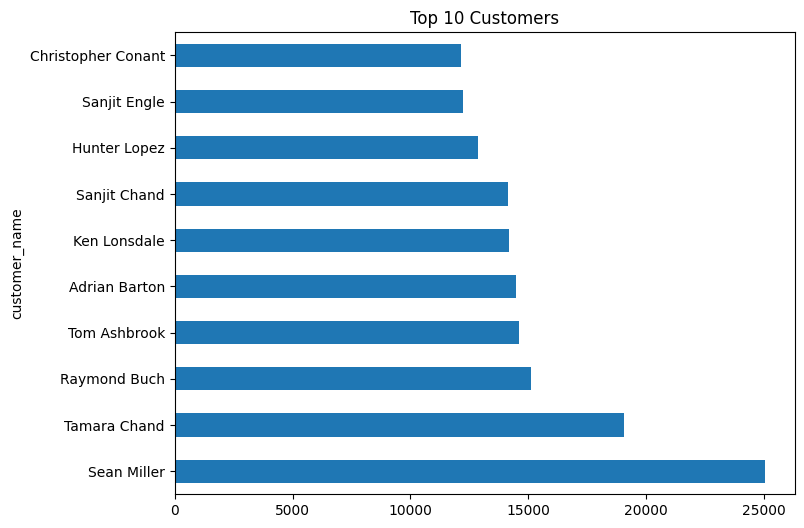

In [299]:
top_customers = (data.groupby('customer_name')['sales'].sum().nlargest(10))

plt.figure(figsize=(8,6))
top_customers.plot(kind='barh')
plt.title('Top 10 Customers')
plt.show()

# Insight
- A small group of customers contributes a significant portion of total sales.
- High-value customers should be prioritized through retention strategies.
- Customer concentration indicates opportunities for targeted marketing.

# Top 10 Products Analysis
**Objective**

Identify best-selling products.

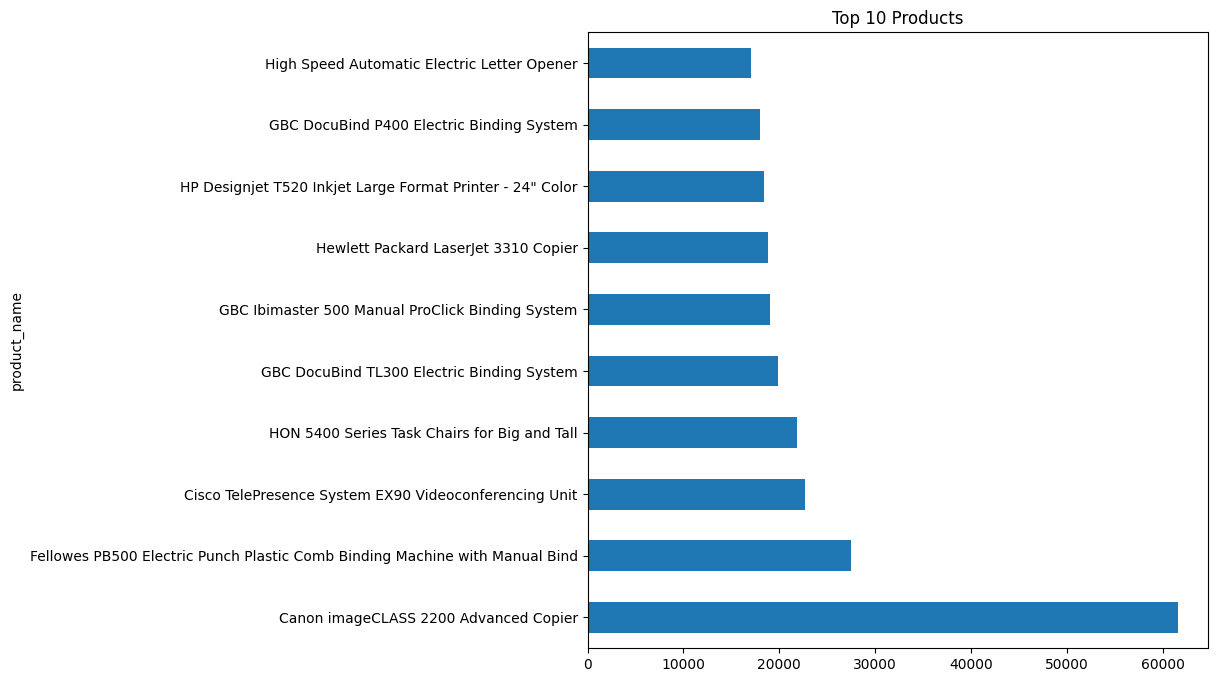

In [300]:
top_products = (data.groupby('product_name')['sales'].sum().nlargest(10))

plt.figure(figsize=(8,8))
top_products.plot(kind='barh')
plt.title('Top 10 Products')
plt.show()

# Insight
- A limited number of products drive a large share of revenue.
- Best-selling products can be prioritized for inventory planning and promotions.
- Product-level analysis helps optimize business decisions.

# Sales Distribution
**Objective**

Understand the distribution of sales transactions.

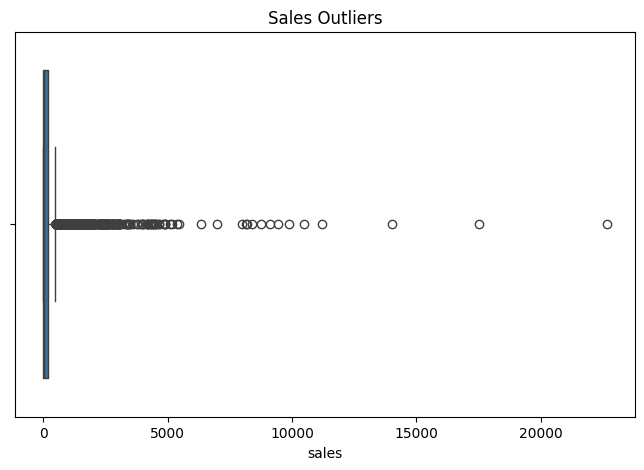

In [309]:
plt.figure(figsize=(8,5))

sns.boxplot(x=data['sales'])

plt.title('Sales Outliers')
plt.show()

# Insight
- Sales distribution is highly right-skewed.
- Most orders have relatively small sales values.
- A few large transactions contribute disproportionately to revenue.
- Significant outliers exist within the dataset.

# Customer Segment Analysis
**Objective**

Analyze revenue contribution by customer segment.

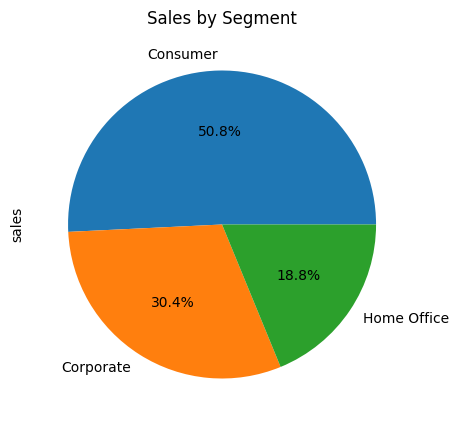

In [314]:
segment_sales = data.groupby('segment')['sales'].sum()

plt.figure(figsize=(6, 5))
segment_sales.plot(kind = 'pie' , autopct = '%1.1f%%')
plt.title('Sales by Segment')
plt.show()

# Insight
- Consumer segment contributes the largest share of sales.
- Corporate and Home Office segments contribute smaller portions.
- Consumer-focused strategies may have the highest business impact.

# Sub-Category Performance Analysis
**Objective**

Evaluate detailed product-level sales performance.

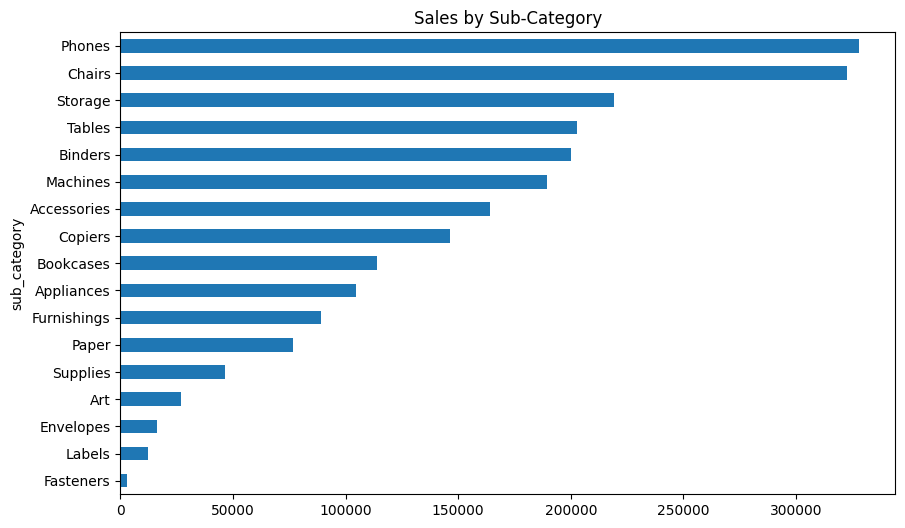

In [359]:
sub_sales = (data.groupby('sub_category')['sales'].sum().sort_values())

plt.figure(figsize=(10,6))
sub_sales.plot(kind='barh')

plt.title('Sales by Sub-Category')
plt.show()

# Insight
- Certain sub-categories generate significantly more revenue than others.
- Sales are concentrated within a few key product groups.
- Identifying top-performing sub-categories supports inventory optimization.

In [357]:
data.rename(columns = {'sub-category' : 'sub_category'} , inplace = True)

# State-wise Sales Analysis
**Objective**

Identify top-performing states.

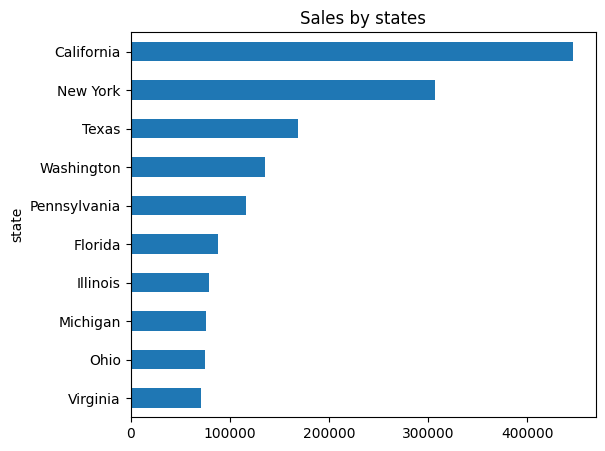

In [341]:
top_states = data.groupby('state')['sales'].sum().nlargest(10)
plt.figure(figsize=(6,5))
top_states.sort_values().plot(kind='barh')
plt.title('Sales by states')
plt.show()

# Insight
- Revenue is concentrated among a few states.
- Top-performing states present opportunities for expansion and customer acquisition.
- Geographic analysis reveals regional demand patterns.

# Delivery Performance Analysis
**Objective**

Evaluate shipping efficiency using delivery days.

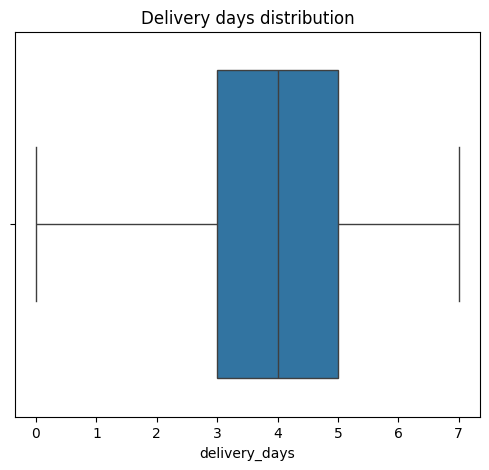

In [340]:
plt.figure(figsize=(6,5))
sns.boxplot(x=data['delivery_days'])
plt.title('Delivery days distribution')
plt.show()

# Insight
- Average delivery time is approximately 4 days.
- Most orders are delivered within a short timeframe.
- Delivery performance appears consistent across the dataset.

In [363]:
data.to_csv('train.csv' , index=False)

# Final Business Insights
**Key Findings**
- Total sales exceeded $2.26 million.
- Technology was the highest revenue-generating category.
- West region recorded the strongest sales performance.
- Consumer customers generated the largest share of revenue.
- Sales demonstrated positive growth over time.
- A small number of customers and products contributed significantly to revenue.
- Delivery performance remained efficient, averaging approximately 4 days.

In [361]:
from urllib.parse import quote_plus

password = quote_plus("Rajiwate@123")

engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}/{database}"
)

In [362]:
data.to_sql(
    'superstore',
    con=engine,
    if_exists='replace',
    index=False
)

9800